In [ ]:
# 1. Импорт библиотек

import numpy as np #для матричных вычислений
import pandas as pd #для анализа и предобработки данных
import matplotlib.pyplot as plt #для визуализации
import seaborn as sns #для визуализации
import torch # импортируем PyTorch
import torch.nn as nn #для создания нейронных сетей
import pytorch_lightning as pl 

from sklearn import linear_model #линейные модели
from sklearn import metrics #метрики
from sklearn import preprocessing #предобработка
from sklearn.model_selection import train_test_split #разделение выборки
from sklearn import ensemble #ансамблевые методы

In [2]:
# 2. Загрузка и анализ данных

train = pd.read_csv('/Users/konstantingeneralov/IDE/Data/DL_PJ_train.csv', sep=',')
test = pd.read_csv('/Users/konstantingeneralov/IDE/Data/DL_PJ_test.csv', sep=',')

df_train = train.copy()
df_test = test.copy()

display(df_train.head(), df_train.info(), df_train.describe())
display(df_test.head(), df_test.info(), df_test.describe())

# проверим кол-ва дубликатов в данных
duplicate_rows_train = df_train.duplicated().sum()
duplicate_rows_test = df_test.duplicated().sum()
print('Количество дубликатов в тренинговой выборке:', duplicate_rows_train)
print('Количество дубликатов в тестовой выборке:', duplicate_rows_test)

# проверим наличие пропущенных значений и уникальных значений в каждом столбце
summary = pd.DataFrame({
    "missing": df_train.isnull().sum(),
    "unique": df_train.nunique(),
    "dtype": df_train.dtypes
})
display('train',summary)

summary = pd.DataFrame({
    "missing": df_test.isnull().sum(),
    "unique": df_test.nunique(),
    "dtype": df_test.dtypes
})
display('test',summary)


<class 'pandas.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 15 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    600000 non-null  int64  
 1   age                                   600000 non-null  float64
 2   sex                                   600000 non-null  int64  
 3   chest                                 600000 non-null  float64
 4   resting_blood_pressure                600000 non-null  float64
 5   serum_cholestoral                     600000 non-null  float64
 6   fasting_blood_sugar                   600000 non-null  int64  
 7   resting_electrocardiographic_results  600000 non-null  int64  
 8   maximum_heart_rate_achieved           600000 non-null  float64
 9   exercise_induced_angina               600000 non-null  int64  
 10  oldpeak                               600000 non-null  float64
 11  slope      

,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,class
0,0,49.207124,0,4.000000,162.996167,181.108682,0,0,148.227858,1,0.944547,2,0,3,1
1,1,53.628425,1,1.741596,130.233730,276.474630,0,2,152.917139,0,0.119070,2,0,3,0
2,2,49.591426,1,4.000000,146.999012,223.300517,1,2,102.352090,1,1.616747,2,2,7,1
3,3,58.991445,1,4.000000,112.369143,187.245501,0,0,158.164750,1,0.000000,1,1,7,1
4,4,51.053602,1,1.954609,138.032047,238.482868,0,0,172.540828,0,1.150464,1,1,3,0


None

,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,class
count,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000
mean,299999.500000,54.426085,0.677447,3.170247,131.340485,249.592420,0.150757,1.020148,149.592069,0.333502,1.051391,1.596033,0.681303,4.711378,0.444185
std,173205.225094,9.086041,0.467454,0.949618,17.842450,51.699976,0.357812,0.994204,23.072593,0.471464,1.144288,0.629821,0.950669,1.934766,0.496875
min,0.000000,26.061695,0.000000,-0.538498,82.918527,98.326263,0.000000,0.000000,61.844168,0.000000,-0.806788,1.000000,0.000000,3.000000,0.000000
25%,149999.750000,48.078493,0.000000,3.000000,119.924094,216.475964,0.000000,0.000000,135.704237,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,299999.500000,55.133425,1.000000,3.000000,129.727941,244.233699,0.000000,2.000000,153.224828,0.000000,0.811101,2.000000,0.000000,3.000000,0.000000
75%,449999.250000,60.663775,1.000000,4.000000,139.915216,274.345453,0.000000,2.000000,165.165497,1.000000,1.674081,2.000000,1.000000,7.000000,1.000000
max,599999.000000,79.591647,1.000000,4.000000,209.673650,527.755764,1.000000,2.000000,208.735196,1.000000,6.803372,3.000000,3.000000,7.000000,1.000000


<class 'pandas.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 14 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    400000 non-null  int64  
 1   age                                   400000 non-null  float64
 2   sex                                   400000 non-null  int64  
 3   chest                                 400000 non-null  float64
 4   resting_blood_pressure                400000 non-null  float64
 5   serum_cholestoral                     400000 non-null  float64
 6   fasting_blood_sugar                   400000 non-null  int64  
 7   resting_electrocardiographic_results  400000 non-null  int64  
 8   maximum_heart_rate_achieved           400000 non-null  float64
 9   exercise_induced_angina               400000 non-null  int64  
 10  oldpeak                               400000 non-null  float64
 11  slope      

...

Количество дубликатов в тренинговой выборке: 0
Количество дубликатов в тестовой выборке: 0


'train'

,missing,unique,dtype
ID,0,600000,int64
age,0,594106,float64
sex,0,2,int64
chest,0,133009,float64
resting_blood_pressure,0,596241,float64
serum_cholestoral,0,598797,float64
fasting_blood_sugar,0,2,int64
resting_electrocardiographic_results,0,3,int64
maximum_heart_rate_achieved,0,597583,float64
exercise_induced_angina,0,2,int64


'test'

,missing,unique,dtype
ID,0,400000,int64
age,0,397391,float64
sex,0,2,int64
chest,0,90257,float64
resting_blood_pressure,0,398274,float64
serum_cholestoral,0,399436,float64
fasting_blood_sugar,0,2,int64
resting_electrocardiographic_results,0,3,int64
maximum_heart_rate_achieved,0,398888,float64
exercise_induced_angina,0,2,int64


## Выводы по этапу загрузки данных и первичного анализа

1. **Данные для обучения и тестирования**
   - Получены два датасета:
     - **train**: 600 000 строк, 15 столбцов (включая целевой признак `class`);
     - **test**: 400 000 строк, 14 столбцов (целевая переменная отсутствует).

2. **Постановка задачи**
   - Целевая переменная — **`class`** (значения 0/1), следовательно решается задача **бинарной классификации**.

3. **Типы признаков**
   - **Категориальные/дискретные признаки**:  
     `sex`, `chest`, `fasting_blood_sugar`, `resting_electrocardiographic_results`,  
     `exercise_induced_angina`, `slope`, `number_of_major_vessels`, `thal`.
   - **Непрерывные числовые признаки**:  
     `age`, `resting_blood_pressure`, `serum_cholestoral`, `maximum_heart_rate_achieved`, `oldpeak`.
   - Отдельно присутствует столбец **`ID`** — это идентификатор записи; он не несёт полезной информации для модели и должен быть исключён из набора признаков при обучении.

4. **Качество данных (пропуски и дубликаты)**
   - **Пропущенных значений и дубликатов** в train и test не обнаружено.

5. **Замечание по признаку `chest`**
   - Признак `chest` по смыслу должен быть **категориальным** (обычно категории 1–4), однако в данных встречаются **вещественные и даже отрицательные** значения.
   - Следовательно, `chest` требует предобработки: приведение к допустимым категориям (например, округление/биннинг), преобразование к целочисленному типу и последующее кодирование.

6. **Общий итог**
   - В целом структура данных корректна и пригодна для дальнейшего EDA и моделирования; основная выявленная проблема на этапе первичного анализа связана с корректной обработкой признака `chest`.

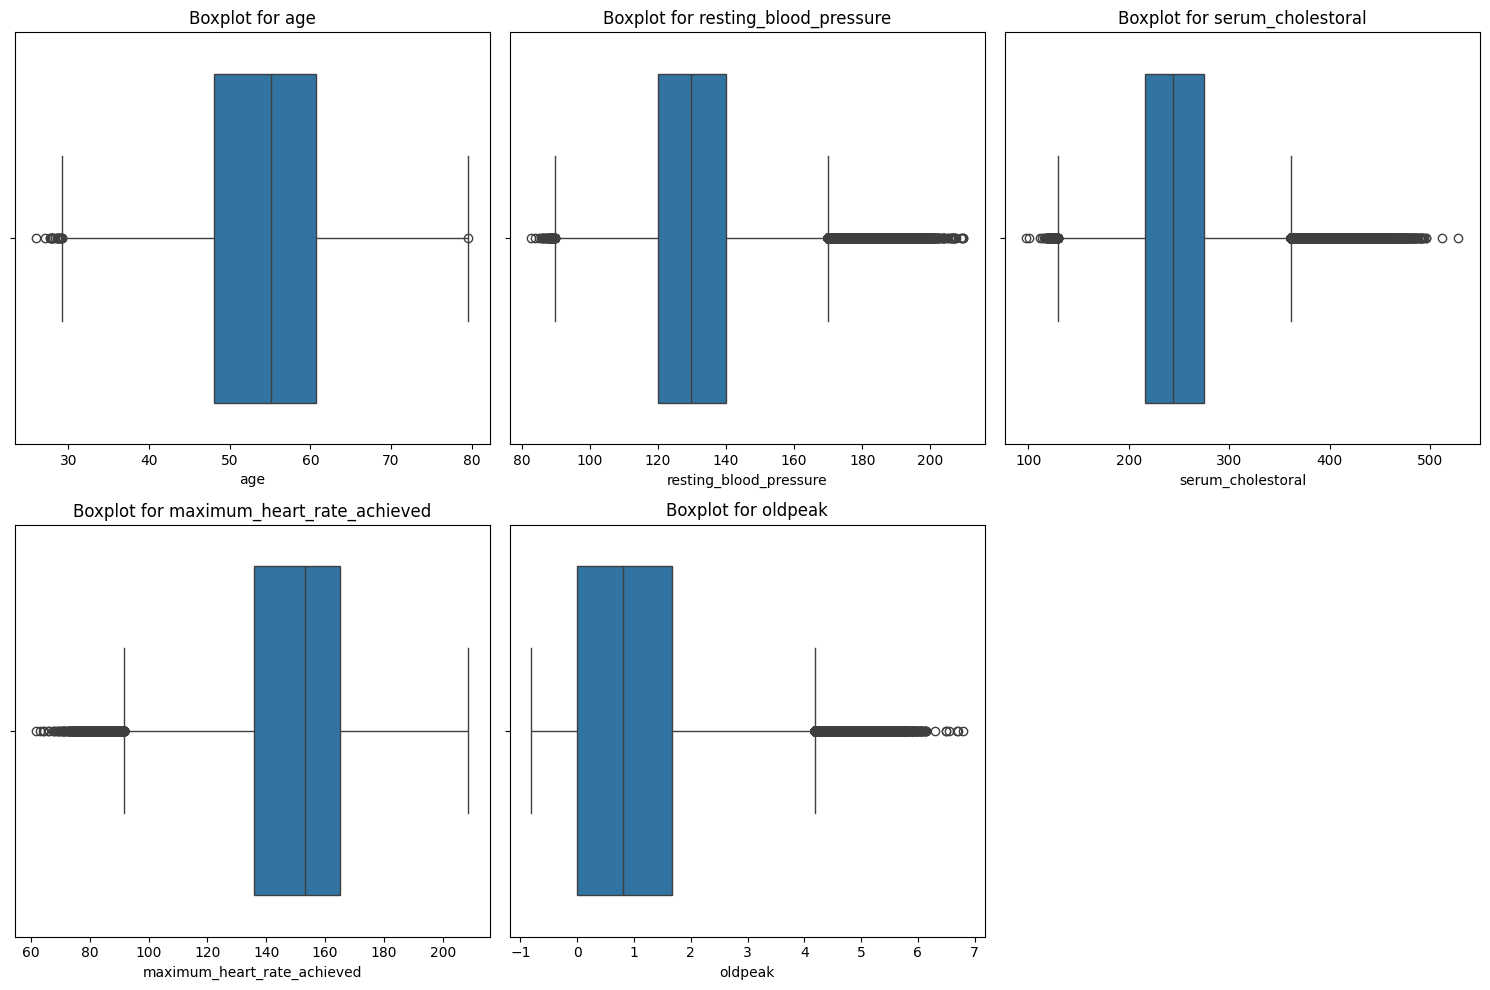

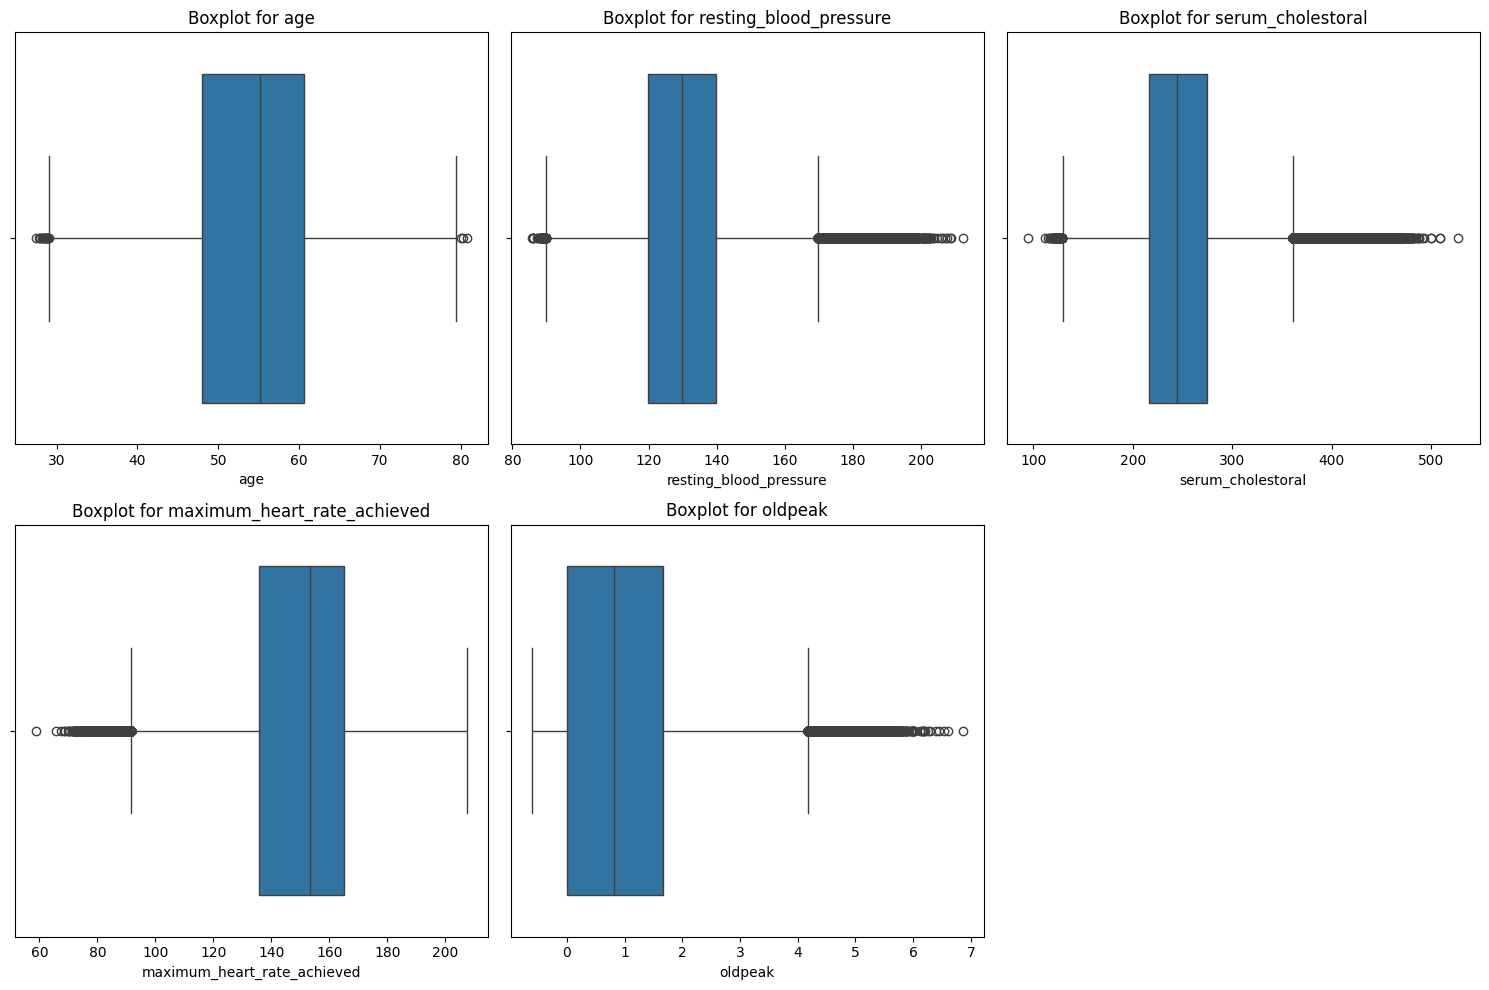

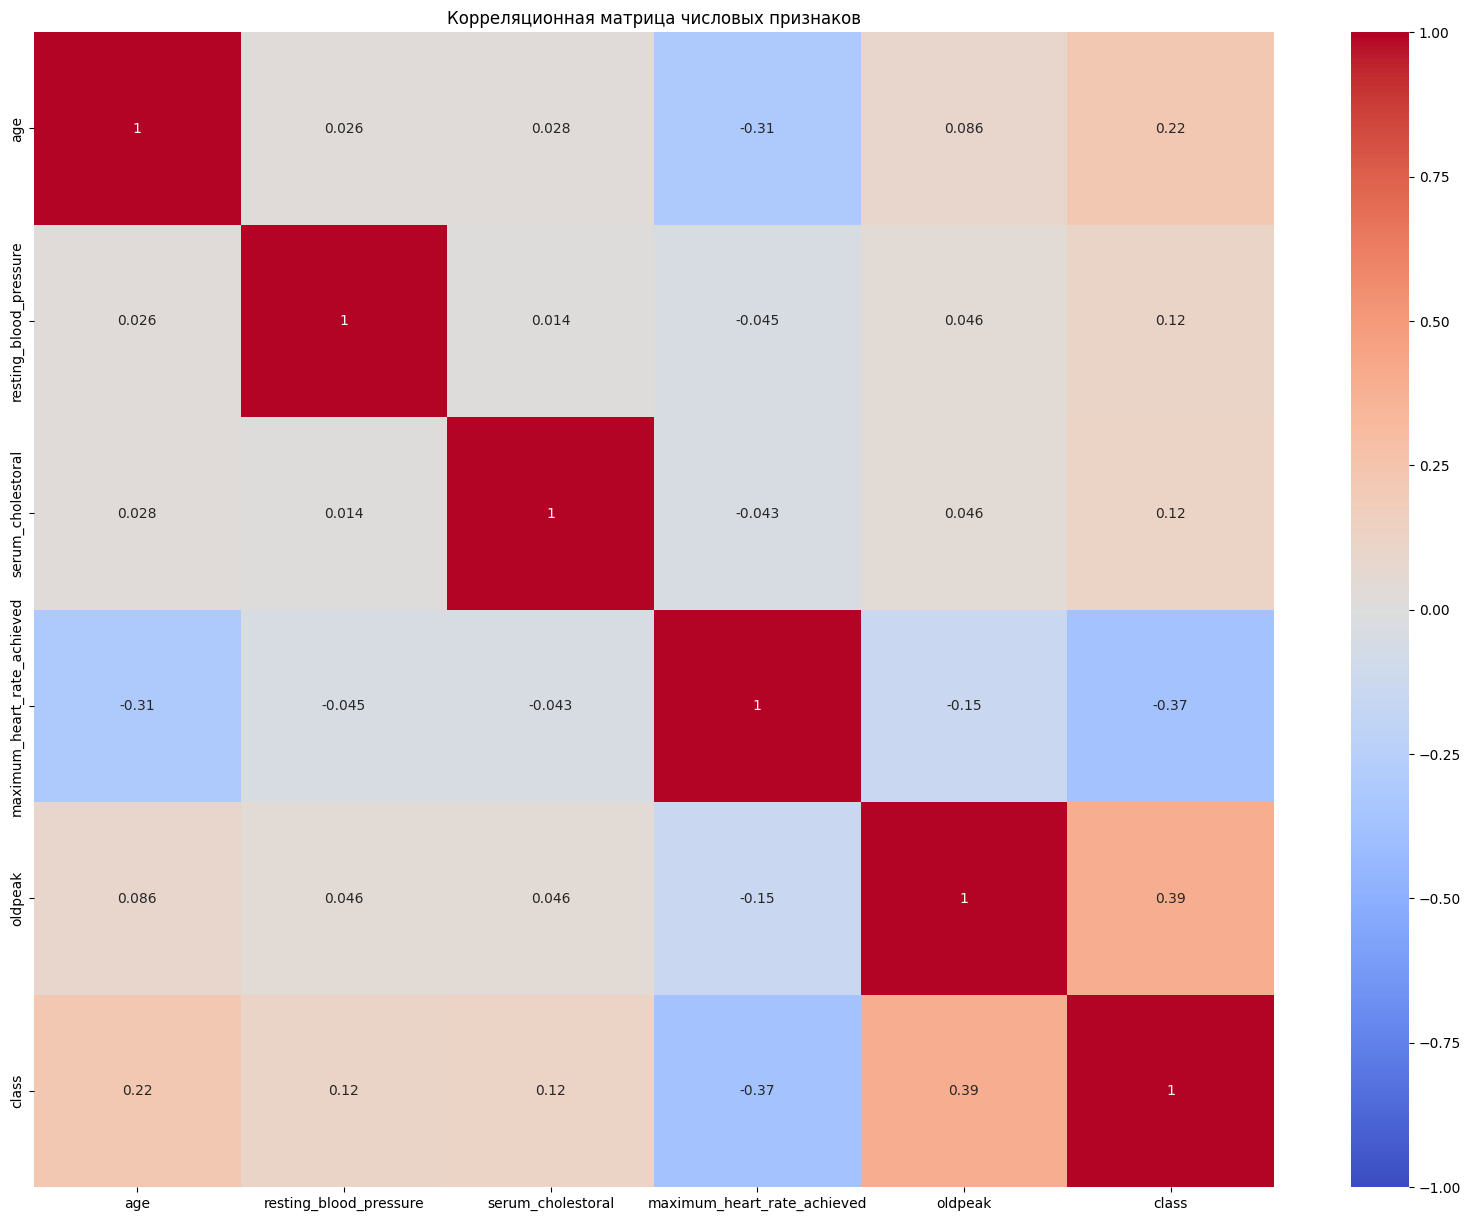

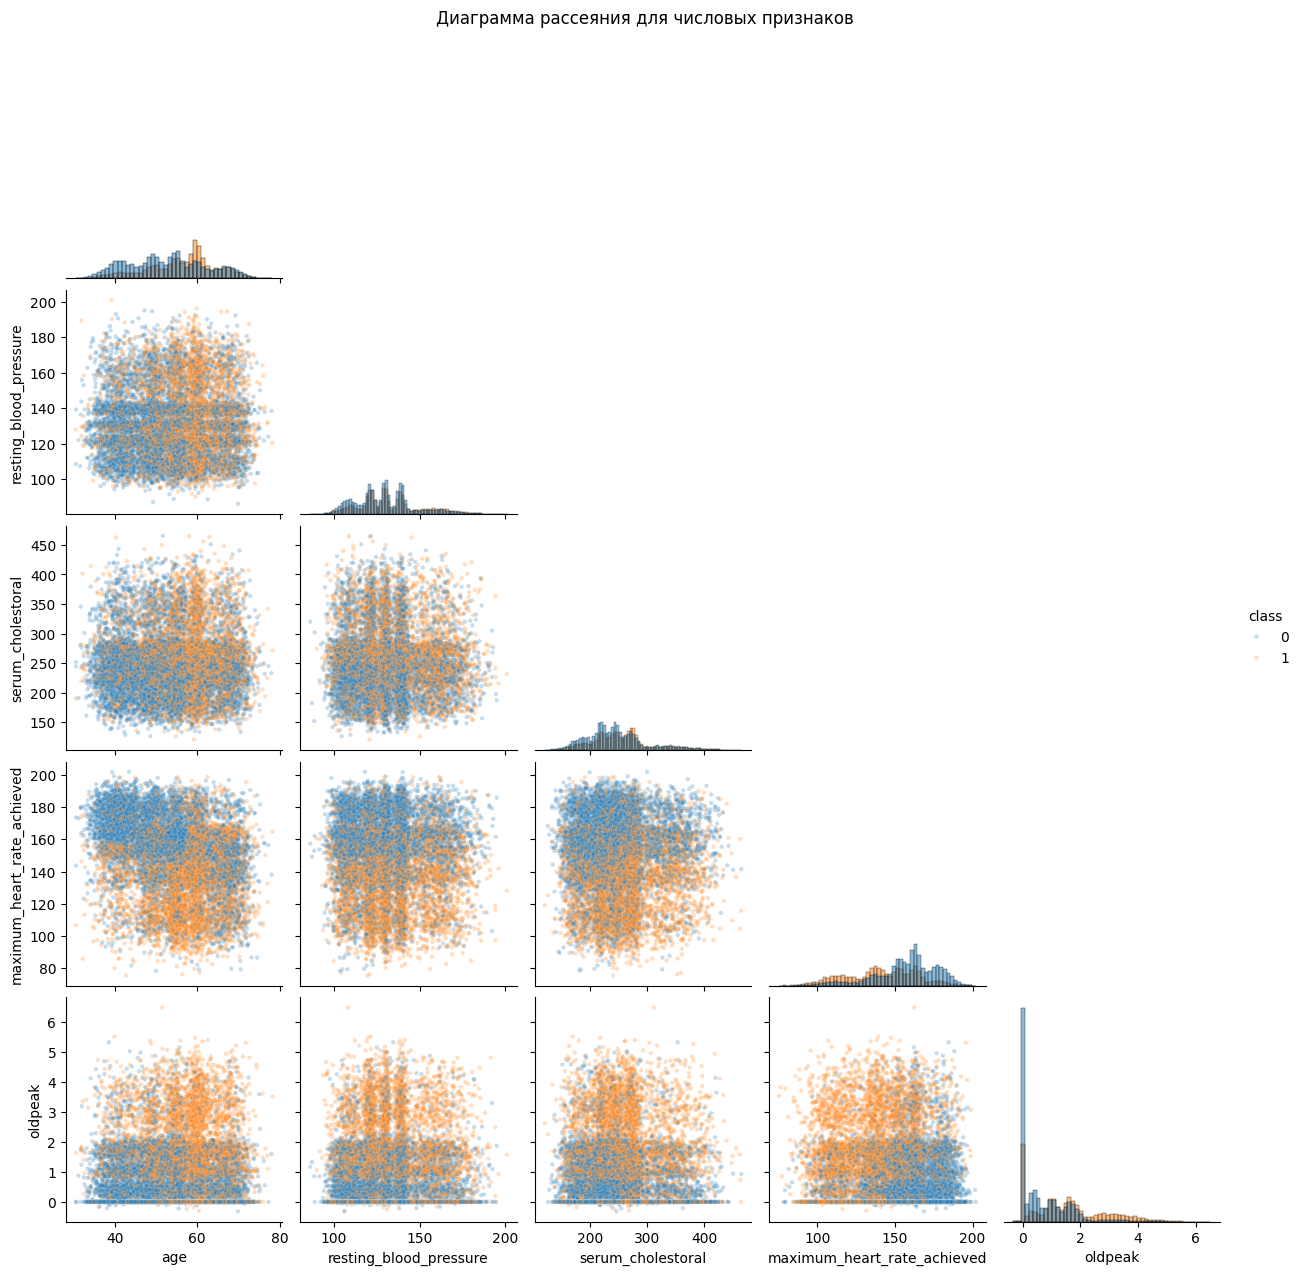

In [ ]:
# 3. Визуальный анализ данных
# посмотрим выбросы в числовых данных train
num_colls = ['age','resting_blood_pressure','serum_cholestoral','maximum_heart_rate_achieved','oldpeak']
plt.figure(figsize=(15,10))
for i, col in enumerate(num_colls):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x=df_train[col])
    plt.title(f'Boxplot for {col}')
plt.tight_layout()
plt.show()

# посмотрим выбросы в числовых данных test
plt.figure(figsize=(15,10))
for i, col in enumerate(num_colls):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x=df_test[col])
    plt.title(f'Boxplot for {col}')
plt.tight_layout()
plt.show()


num_colls_2 = ['age','resting_blood_pressure','serum_cholestoral','maximum_heart_rate_achieved','oldpeak','class']
# построим корреляционную матрицу для числовых признаков train
plt.figure(figsize=(20,15))
corr_matrix = df_train[num_colls_2].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Корреляционная матрица числовых признаков')
plt.show()  

# диаграмма рассеяния для числовых признаков train

dfp = df_train[num_colls_2].sample(15000, random_state=42)

sns.pairplot(dfp, hue='class', corner=True, diag_kind='hist',plot_kws={'alpha': 0.25, 's': 10})
plt.suptitle('Диаграмма рассеяния для числовых признаков', y=1.02)
plt.show()


## Выводы по EDA (графики)

### 1) Анализ выбросов (boxplot)
- По boxplot видно наличие выбросов в числовых признаках, особенно в `oldpeak`, а также выраженные «хвосты» у `serum_cholestoral` и `resting_blood_pressure`.
- При этом значения в целом остаются в разумных диапазонах и не выглядят как явно ошибочные/нефизиологичные (например, давление и ЧСС не принимают отрицательных значений).
- Так как в качестве базовой модели используется **RandomForest**, который достаточно устойчив к выбросам и не требует строгой нормализации распределений, выбросы **не удалялись и не клиппировались**, чтобы не потерять потенциально информативные наблюдения.

### 2) Корреляционная матрица (числовые непрерывные признаки)
- Наиболее заметная связь с целевой переменной `class`:
  - `oldpeak` — умеренная положительная корреляция (≈ 0.39);
  - `maximum_heart_rate_achieved` — умеренная отрицательная корреляция (≈ -0.37);
  - `age` — слабая положительная корреляция (≈ 0.22).
- Между самими непрерывными признаками сильной мультиколлинеарности не наблюдается; выделяется ожидаемая зависимость `age` и `maximum_heart_rate_achieved` (≈ -0.31).

### 3) Диаграммы рассеяния (scatter/pairplot)
- Визуально классы **сильно перекрываются** практически во всех парах признаков: простой линейной разделимости не наблюдается.
- Это подтверждает, что для решения задачи целесообразно использовать модели, способные учитывать **нелинейные зависимости и взаимодействия признаков** (например, RandomForest).

In [ ]:
# 4. Обработка данных

df_train_1 = df_train.copy()
df_test_1 = df_test.copy()

# удалим столбец id, так как он не несет полезной информации для модели
df_train_1 = df_train_1.drop('ID', axis=1)


# приведем в порядок столбец chest так как в нем должны быть категории 1 2 3 4 int 

def fix_chest(s: pd.Series) -> pd.Series:   # функция для обработки столбца chest
    # 1) округляем до ближайшего целого
    s = s.round()
    # 2) ограничиваем диапазоном 1..4
    s = s.clip(1, 4)
    # 3) в int
    return s.astype(int)

df_train_1["chest"] = fix_chest(df_train_1["chest"])
df_test_1["chest"]  = fix_chest(df_test_1["chest"])


# проверим наличие пропущенных значений и уникальных значений в каждом столбце
summary = pd.DataFrame({
    "missing": df_train_1.isnull().sum(),
    "unique": df_train_1.nunique(),
    "dtype": df_train_1.dtypes
})
display('train',summary)

summary = pd.DataFrame({
    "missing": df_test_1.isnull().sum(),
    "unique": df_test_1.nunique(),
    "dtype": df_test_1.dtypes
})
display('test',summary)

#display(df_train_1.head(), df_train_1.info(), df_train_1.describe())
#display(df_test_1.head(), df_test_1.info(), df_test_1.describe())

'train'

,missing,unique,dtype
age,0,594106,float64
sex,0,2,int64
chest,0,4,int64
resting_blood_pressure,0,596241,float64
serum_cholestoral,0,598797,float64
fasting_blood_sugar,0,2,int64
resting_electrocardiographic_results,0,3,int64
maximum_heart_rate_achieved,0,597583,float64
exercise_induced_angina,0,2,int64
oldpeak,0,384255,float64


'test'

,missing,unique,dtype
ID,0,400000,int64
age,0,397391,float64
sex,0,2,int64
chest,0,4,int64
resting_blood_pressure,0,398274,float64
serum_cholestoral,0,399436,float64
fasting_blood_sugar,0,2,int64
resting_electrocardiographic_results,0,3,int64
maximum_heart_rate_achieved,0,398888,float64
exercise_induced_angina,0,2,int64


## chest превратился в категориальные данные

In [24]:
# делаем one-hot encoding для категориальных признаков
cat_coll = ['sex','chest','fasting_blood_sugar','resting_electrocardiographic_results','exercise_induced_angina','slope','number_of_major_vessels','thal']
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(
    sparse_output=False,      # укажем что хотим получить плотный массив это значит что результат будет в виде DataFrame, а не разреженной матрицы
    drop='first',           # удаляем первую категорию, чтобы избежать мультиколлинеарности
    handle_unknown='ignore' # игнорируем неизвестные категории при трансформации тестовых данных
)

df_train_1_encoded = pd.DataFrame(
    encoder.fit_transform(df_train_1[cat_coll]), 
    index=df_train_1.index,
    columns=encoder.get_feature_names_out(cat_coll)
)

df_test_1_encoded = pd.DataFrame(
    encoder.transform(df_test_1[cat_coll]), # трансформируем тестовые данные
    index=df_test_1.index,                  # сохраняем индексы для корректного объединения с числовыми признаками
    columns=encoder.get_feature_names_out(cat_coll) # получаем имена новых признаков
)


#display(df_train_1_encoded.head(), df_train_1_encoded.info(), df_train_1_encoded.describe())
#display(df_test_1_encoded.head(), df_test_1_encoded.info(), df_test_1_encoded.describe())


## Мы получили два новых датафрема с категориальными признаками переделаные с one hot encoding 

In [ ]:
# 5. Обучаем модели

num_colls = ['age','resting_blood_pressure','serum_cholestoral','maximum_heart_rate_achieved','oldpeak'] # создаем список числовых признаков для удобства

target_col = 'class'                  # целевая переменная
x_train_num = df_train_1[num_colls]   # выделяем числовые признаки из тренировочных данных
x_test_num = df_test_1[num_colls]     # выделяем числовые признаки из тестовых данных

X_train = pd.concat([x_train_num, df_train_1_encoded], axis=1) # склеили колонки числовые и закодированные категориальные
X_test = pd.concat([x_test_num, df_test_1_encoded], axis=1) # склеили колонки числовые и закодированные категориальные

y_train = df_train_1[target_col].astype(int) 


print("X_train:", X_train.shape, "y_train:", y_train.shape, "X_test:", X_test.shape)




X_train: (600000, 20) y_train: (600000,) X_test: (400000, 20)


In [26]:
# Разделим данные на обучающую и валидационную выборки
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train)

print("X_tr:", X_tr.shape, "y_tr:", y_tr.shape, "X_val:", X_val.shape, "y_val:", y_val.shape)

X_tr: (480000, 20) y_tr: (480000,) X_val: (120000, 20) y_val: (120000,)


In [30]:
# используем логистическую регрессию

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

scaler = StandardScaler()  # создаем экземпляр стандартизатора для числовых признаков

X_tr_lr = X_tr.copy()     # создаем копию обучающей выборки для логистической регрессии, чтобы не изменять оригинальные данные
X_val_lr = X_val.copy()   # создаем копию валидационной выборки для логистической регрессии, чтобы не изменять оригинальные данные

X_tr_lr[num_colls] = scaler.fit_transform(X_tr_lr[num_colls]) # стандартизируем числовые признаки в обучающей выборке, используя fit_transform для обучения стандартизатора на обучающей выборке
X_val_lr[num_colls] = scaler.transform(X_val_lr[num_colls]) # стандартизируем числовые признаки в валидационной выборке, используя transform для применения обученного стандартизатора

logreg = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced') # создаем экземпляр логистической регрессии с увеличенным количеством итераций для гарантированного сходимости и балансировкой классов
logreg.fit(X_tr_lr, y_tr)  # обучаем логистическую регрессию на стандартизированных данных

val_proba_lr = logreg.predict_proba(X_val_lr)[:, 1] # получаем вероятности положительного класса для валидационной выборки, так как roc_auc_score требует вероятности, а не классы
print("LogReg ROC-AUC:", roc_auc_score(y_val, val_proba_lr))

LogReg ROC-AUC: 0.9557003313691899


In [ ]:
# обучим модель случайного леса

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,                 # количество деревьев в лесу
    random_state=42,                  # фиксируем random_state для воспроизводимости результатов
    n_jobs=-1,
    class_weight="balanced_subsample" # используем balanced_subsample для балансировки классов на каждом бутстрапе
)
rf.fit(X_tr, y_tr)

val_proba_rf = rf.predict_proba(X_val)[:, 1]
print("RF ROC-AUC:", roc_auc_score(y_val, val_proba_rf))

RF ROC-AUC: 0.960440242086257


## Выводы по этапу обучения моделей

1. **Подготовка данных для оценки качества**
   - Для объективной оценки качества модели обучающая выборка `train` была разделена на **train/validation**.

2. **Модель 1 — Логистическая регрессия**
   - В качестве базовой линейной модели обучена **Logistic Regression**.
   - Для корректной работы линейной модели числовые признаки были **стандартизированы** с помощью `StandardScaler`
     (обучение скейлера выполнено только на train-части, затем применено к validation, чтобы избежать утечки).
   - Качество на валидационной выборке: **ROC-AUC = 0.9557**.

3. **Модель 2 — Случайный лес**
   - Обучен **RandomForestClassifier** (ансамбль деревьев), который хорошо учитывает нелинейности и взаимодействия признаков,
     а также устойчив к выбросам.
   - Качество на валидационной выборке: **ROC-AUC = 0.9604**.

4. **Итоговый выбор модели**
   - Так как **RandomForest** показал более высокое значение ROC-AUC на валидации, именно он выбран в качестве итоговой модели
     для построения предсказаний на тестовой выборке и формирования файла submission.

In [ ]:
# Трекнируем на всей тренинговой выборке

best_rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

best_rf.fit(X_train, y_train) 

# Делаем предсказания на тестовой выборке и сохраняем результат в файл для сабмита

test_proba = best_rf.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= 0.5).astype(int)

submission = pd.DataFrame({
    "ID": df_test_1["ID"].values,
    "class": test_pred
})

submission.to_csv("/Users/konstantingeneralov/IDE/Data/DL_PJ_submission_2.csv", index=False)
submission.head()

,ID,class
0,600000,1
1,600001,1
2,600002,0
3,600003,0
4,600004,0


## Выводы по этапу предсказания и формированию submission

- С использованием выбранной итоговой модели **RandomForestClassifier** были получены предсказания для тестовой выборки.
- Для каждого объекта тестовой выборки рассчитан прогноз класса `class` (на основе вероятности положительного класса и порога 0.5).
- Результаты сохранены в файл **`DL_PJ_submission_2.csv`** в требуемом формате: две колонки **`ID`** и **`class`**, где `ID` используется только для идентификации строк и сопоставления предсказаний с исходными объектами.

In [ ]:
# переведем данные в float32 для обучения нейронной сети, так как PyTorch по умолчанию работает с float32 и это может ускорить обучение и снизить потребление памяти

X_tr_nn = X_tr_lr.to_numpy().astype(np.float32) # преобразуем DataFrame в numpy массив и приводим тип данных к float32
X_val_nn = X_val_lr.to_numpy().astype(np.float32)
y_tr_nn = y_tr.to_numpy().astype(np.float32).reshape(-1, 1) # reshape для получения двумерного массива (n_samples, 1), так как PyTorch ожидает такую форму для целевой переменной при бинарной классификации
y_val_nn = y_val.to_numpy().astype(np.float32).reshape(-1, 1)

print(X_tr_nn.dtype, y_tr_nn.dtype)

float32 float32


In [33]:
# Шаг 2: Dataset + DataLoader (подача данных батчами)
from torch.utils.data import Dataset, DataLoader

class TabularDataset(Dataset):
    def __init__(self, X, y):
        # X: numpy array float32 shape (N, n_features)
        # y: numpy array float32 shape (N, 1)
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
batch_size = 1024  # можно 512/1024; если будет RAM тяжело — уменьшим

train_ds = TabularDataset(X_tr_nn, y_tr_nn)
val_ds = TabularDataset(X_val_nn, y_val_nn)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)

# sanity-check: посмотрим один батч
xb, yb = next(iter(train_loader))
print("xb:", xb.shape, xb.dtype)
print("yb:", yb.shape, yb.dtype)

xb: torch.Size([1024, 20]) torch.float32
yb: torch.Size([1024, 1]) torch.float32


In [36]:
# Шаг 3 — пишем Neural Network (MLP) как LightningModule и готовим обучение
from torch.optim import Adam
class MLP(pl.LightningModule):
    def __init__(self, n_features, lr=1e-3, hidden_sizes=(128, 64), dropout=0.2):
        super().__init__()
        self.save_hyperparameters()  # Lightning сохранит параметры в checkpoint (удобно для воспроизводимости)

        # ----- 1) Архитектура сети -----
        layers = []
        in_dim = n_features

        # Делает блоки: Linear -> ReLU -> Dropout
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))   # полносвязный слой
            layers.append(nn.ReLU())              # нелинейность
            layers.append(nn.Dropout(dropout))    # регуляризация (чтобы меньше переобучалась)
            in_dim = h

        # Последний слой: 1 число (logit) для бинарной классификации
        layers.append(nn.Linear(in_dim, 1))

        self.net = nn.Sequential(*layers)

        # ----- 2) Функция потерь -----
        # BCEWithLogitsLoss = sigmoid + BCE в одном (численно устойчивее, чем делать sigmoid отдельно)
        self.loss_fn = nn.BCEWithLogitsLoss()

        self.lr = lr

        # сюда будем собирать предсказания на val, чтобы посчитать ROC-AUC за всю эпоху
        self.val_probs = []
        self.val_targets = []

    def forward(self, x):
        # forward = как сеть превращает признаки в logits
        return self.net(x)

    def training_step(self, batch, batch_idx):
        # batch = (X_batch, y_batch)
        x, y = batch

        logits = self(x)                # (batch, 1)
        loss = self.loss_fn(logits, y)  # сравниваем logits и y

        # log — чтобы Lightning сохранял это в историю (для графиков)
        self.log("train_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def on_validation_epoch_start(self):
        # перед началом каждой эпохи валидации очищаем списки
        self.val_probs = []
        self.val_targets = []

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)

        # logits -> probability
        probs = torch.sigmoid(logits)

        # копим все батчи на CPU (так безопаснее для numpy+sklearn)
        self.val_probs.append(probs.detach().cpu())
        self.val_targets.append(y.detach().cpu())

        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def on_validation_epoch_end(self):
        # склеиваем все батчи в один массив
        probs = torch.cat(self.val_probs, dim=0).numpy().reshape(-1)
        targets = torch.cat(self.val_targets, dim=0).numpy().reshape(-1)

        # считаем ROC-AUC на вероятностях
        val_roc_auc = roc_auc_score(targets, probs)

        # логируем метрику — именно по ней будем сохранять лучшие веса
        self.log("val_roc_auc", val_roc_auc, prog_bar=True)

    def configure_optimizers(self):
        # оптимизатор, который обновляет веса сети
        return Adam(self.parameters(), lr=self.lr)
    
# создаем модель
n_features = X_tr_nn.shape[1]
model = MLP(n_features=n_features, lr=1e-3, hidden_sizes=(128, 64), dropout=0.2)
model

# Trainer + сохранение лучших весов (checkpoint)
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

checkpoint_cb = ModelCheckpoint(
    monitor="val_roc_auc",
    mode="max",
    save_top_k=1,
    filename="best-mlp-{epoch:02d}-{val_roc_auc:.4f}"
)

early_stop_cb = EarlyStopping(
    monitor="val_roc_auc",
    mode="max",
    patience=5
)

trainer = pl.Trainer(
    max_epochs=30,
    callbacks=[checkpoint_cb, early_stop_cb],
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50
)

# запускаем обучение
trainer.fit(model, train_loader, val_loader)

print("Best checkpoint path:", checkpoint_cb.best_model_path)
print("Best val_roc_auc:", checkpoint_cb.best_model_score)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name    | Type              | Params | Mode  | FLOPs
--------------------------------------------------------------
0 | net     | Sequential        | 11.0 K | train | 0    
1 | loss_fn | BCEWithLogitsLoss | 0      | train | 0    
--------------------------------------------------------------
11.0 K    Trainable params
0         Non-trainable params
11.0 K    Total params
0.044     Total estimated model params size (MB)
9         Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/konstantingeneralov/IDE/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/konstantingeneralov/IDE/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


/Users/konstantingeneralov/IDE/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/konstantingeneralov/IDE/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


Epoch 29: 100%|██████████| 469/469 [00:02<00:00, 185.01it/s, v_num=0, val_loss=0.243, val_roc_auc=0.963, train_loss=0.245]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 469/469 [00:02<00:00, 184.41it/s, v_num=0, val_loss=0.243, val_roc_auc=0.963, train_loss=0.245]
Best checkpoint path: /Users/konstantingeneralov/IDE/sf_data_science/tasks/lightning_logs/version_0/checkpoints/best-mlp-epoch=29-val_roc_auc=0.9632.ckpt
Best val_roc_auc: tensor(0.9632, device='mps:0')


In [40]:
# Прочитать metrics.csv и построить графики

train_loss = pd.read_csv("/Users/konstantingeneralov/IDE/sf_data_science/tasks/lightning_logs/version_0/version_0.csv")
val_loss = pd.read_csv("/Users/konstantingeneralov/IDE/sf_data_science/tasks/lightning_logs/version_0/version_0-2.csv")
val_auc = pd.read_csv("/Users/konstantingeneralov/IDE/sf_data_science/tasks/lightning_logs/version_0/version_0-3.csv")


display(train_loss.head(), val_loss.head(), val_auc.head())


,Wall time,Step,Value
0,1.774701e+09,468,0.296764
1,1.774701e+09,937,0.260911
2,1.774701e+09,1406,0.257872
3,1.774701e+09,1875,0.255699
4,1.774701e+09,2344,0.254435


,Wall time,Step,Value
0,1.774701e+09,468,0.257159
1,1.774701e+09,937,0.253782
2,1.774701e+09,1406,0.252488
3,1.774701e+09,1875,0.251392
4,1.774701e+09,2344,0.250596


,Wall time,Step,Value
0,1.774701e+09,468,0.958917
1,1.774701e+09,937,0.959933
2,1.774701e+09,1406,0.960257
3,1.774701e+09,1875,0.960582
4,1.774701e+09,2344,0.960862


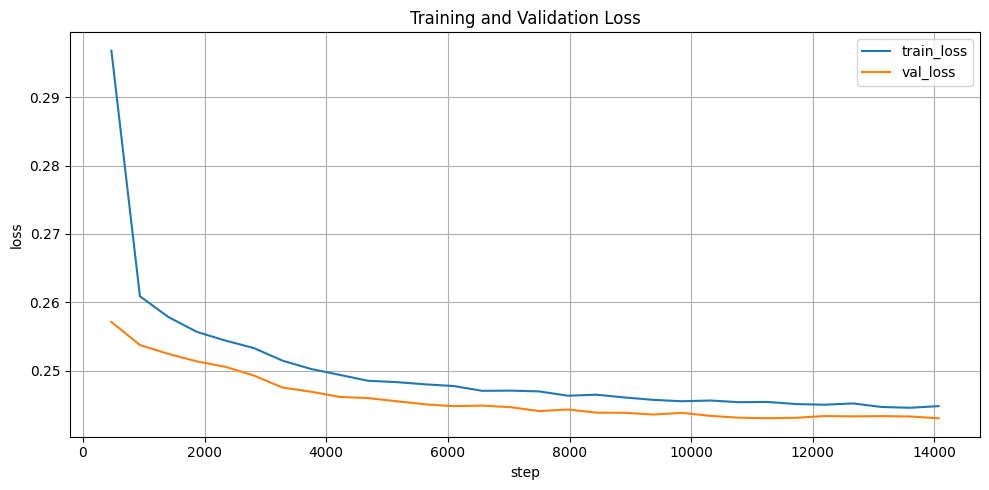

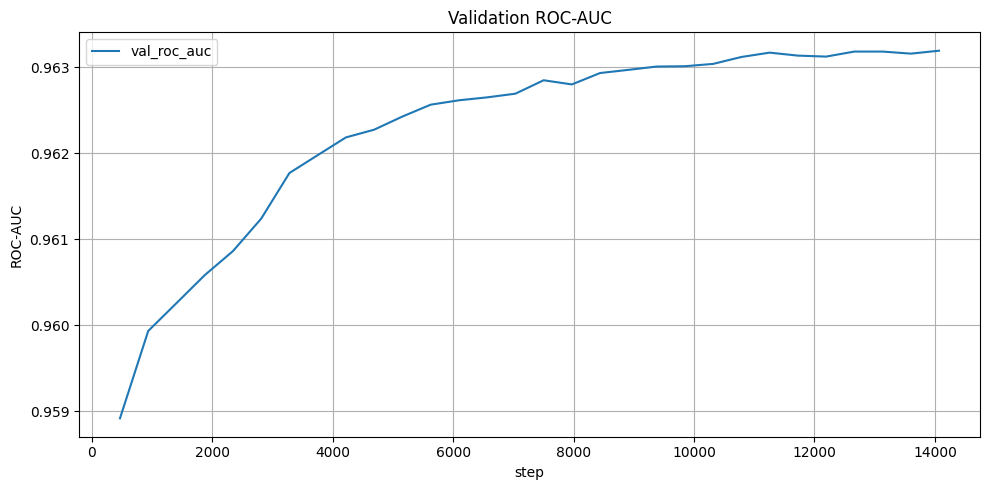

In [42]:
import os

# Ensure the 'images' directory exists
os.makedirs("images", exist_ok=True)

# ----- Loss plot -----
plt.figure(figsize=(10, 5))
plt.plot(train_loss["Step"], train_loss["Value"], label="train_loss")
plt.plot(val_loss["Step"], val_loss["Value"], label="val_loss")
plt.title("Training and Validation Loss")
plt.xlabel("step")
plt.ylabel("loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("images/loss_curve.png", dpi=200)
plt.show()

# ----- ROC-AUC plot -----
plt.figure(figsize=(10, 5))
plt.plot(val_auc["Step"], val_auc["Value"], label="val_roc_auc")
plt.title("Validation ROC-AUC")
plt.xlabel("step")
plt.ylabel("ROC-AUC")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("images/roc_auc_curve.png", dpi=200)
plt.show()

## Loss (train vs val)

- Значения train_loss и val_loss монотонно снижаются по мере обучения, что говорит о корректной оптимизации.
- Кривые train/val идут близко друг к другу, сильного расхождения нет следовательно явных признаков переобучения не наблюдается.
- К концу обучения наблюдается плато: дальнейшее снижение loss замедляется, что означает приближение к оптимуму при текущей архитектуре/гиперпараметрах.

## ROC-AUC на валидации

- Метрика ROC-AUC стабильно растёт на протяжении обучения.
- Рост постепенно замедляется и выходит на плато около ~0.963, что подтверждает сходимость модели.
- Итоговый результат на валидации: val ROC-AUC = 0.9632 (лучшая эпоха сохранялась через ModelCheckpoint по val_roc_auc).

## Выводы

- Полносвязная нейронная сеть (MLP) на PyTorch Lightning успешно обучилась на табличных данных.
- Обучение было стабильным: loss убывает, ROC-AUC растёт и стабилизируется.
- Лучшие веса модели сохранены автоматически (через ModelCheckpoint) по максимальному val_roc_auc, лучший результат: 0.9632.
- Полученные кривые показывают хорошую сходимость и отсутствие явного переобучения.

In [43]:
import os, shutil, glob

best_ckpt_path = "/Users/konstantingeneralov/IDE/sf_data_science/tasks/lightning_logs/version_0/checkpoints/best-mlp-epoch=29-val_roc_auc=0.9632.ckpt"

os.makedirs("models", exist_ok=True)

dst_path = "models/mlp_best.ckpt"
shutil.copy(best_ckpt_path, dst_path)

print("Saved to:", dst_path)

Saved to: models/mlp_best.ckpt


In [44]:
import joblib

# проверка, что scaler существует
print("scaler:", type(scaler))

os.makedirs("artifacts", exist_ok=True)
joblib.dump(scaler, "artifacts/scaler.pkl")

print("Scaler saved to: artifacts/scaler.pkl")

scaler: <class 'sklearn.preprocessing._data.StandardScaler'>
Scaler saved to: artifacts/scaler.pkl


In [45]:
ckpt_path = "models/mlp_best.ckpt"

best_model = MLP.load_from_checkpoint(ckpt_path)
best_model.eval()

print("Loaded model from:", ckpt_path)

Loaded model from: models/mlp_best.ckpt


In [54]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
best_model = best_model.to(device)

with torch.no_grad():
    x = torch.from_numpy(X_val_nn).to(device)          # (N, features)
    logits = best_model(x).cpu().numpy().reshape(-1)   # logits -> numpy
    probs = 1 / (1 + np.exp(-logits))                  # sigmoid

val_auc = roc_auc_score(y_val_nn.reshape(-1), probs)
print("VAL ROC-AUC (loaded checkpoint):", val_auc)

VAL ROC-AUC (loaded checkpoint): 0.9631927146524348


In [ ]:
# 1) числовые как DataFrame в том же порядке
x_test_num_df = df_test_1[num_colls].astype(np.float32)

# 2) transform -> вернётся numpy, оборачиваем обратно в DataFrame
x_test_num_scaled = pd.DataFrame(
    scaler.transform(x_test_num_df),
    index=x_test_num_df.index,
    columns=num_colls
).astype(np.float32)

# 3) OHE как float32
x_test_cat = df_test_1_encoded.astype(np.float32)

# 4) Склеиваем (и сохраняем порядок колонок!)
X_test_df = pd.concat([x_test_num_scaled, x_test_cat], axis=1)

# 5) В numpy для нейросети
X_test_nn = X_test_df.to_numpy().astype(np.float32)

print("X_test_nn:", X_test_nn.shape, X_test_nn.dtype)

print("train features:", X_tr_nn.shape[1])
print("test features:", X_test_nn.shape[1])

X_test_nn: (400000, 20) float32
train features: 20
test features: 20


In [61]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = MLP.load_from_checkpoint("models/mlp_best.ckpt").to(device)
model.eval()

with torch.no_grad():
    x = torch.from_numpy(X_test_nn).to(device)
    logits = model(x).cpu().numpy().reshape(-1)
    probs = 1 / (1 + np.exp(-logits))  # sigmoid

# сохраняем с ID
submission_nn = pd.DataFrame({
    "ID": df_test_1["ID"].values,
    "proba": probs
})

submission_nn.to_csv("predictions_nn.csv", index=False)

print("Saved predictions_nn.csv:", submission_nn.shape)
submission_nn.head()

Saved predictions_nn.csv: (400000, 2)


,ID,proba
0,600000,0.990639
1,600001,0.984694
2,600002,0.011263
3,600003,0.122600
4,600004,0.020080
